# Sorting Algorithm Performance Analysis

This notebook analyzes the performance metrics of various sorting algorithms stored in `stats.csv`. We will aggregate the data, validate its integrity, check for fairness across tests, and visualize the results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import io

sns.set_theme(style="dark")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading

Load the `stats.csv` file. We handle the case where the header and data columns might be mismatched (e.g., missing Mean Runtime).

In [2]:
try:
    # Read the file and pad missing columns with empty strings (which become NaN)
    with open('stats.csv', 'r') as f:
        lines = f.readlines()
    
    header = lines[0].strip()
    data_lines = lines[1:]
    # Create CSV content and read with pandas
    csv_content = header + '\n' + '\n'.join(data_lines)
    df = pd.read_csv(io.StringIO(csv_content))
    
    # Convert numeric columns
    numeric_cols = ['Size', 'Comparisons', 'Swaps', 'Writes', 'Min Runtime', 'Max Runtime', 'Mean Runtime']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    print("Data Loaded Successfully.")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")

Data Loaded Successfully.


,Algorithm,Size,Comparisons,Swaps,Writes,Min Runtime,Max Runtime,Mean Runtime
0,BUBBLE,100,9900,2675,0,0.730762,5.699979,1.640030
1,SELECTION,100,4950,93,0,0.297265,1.742362,0.902543
2,INSERTION,100,2774,2675,94,0.717661,1.574136,0.980080
3,MERGE,100,542,0,672,0.121488,0.439284,0.258584
4,QUICK,100,671,488,0,0.059541,0.268319,0.149490


## 2. Visualizations

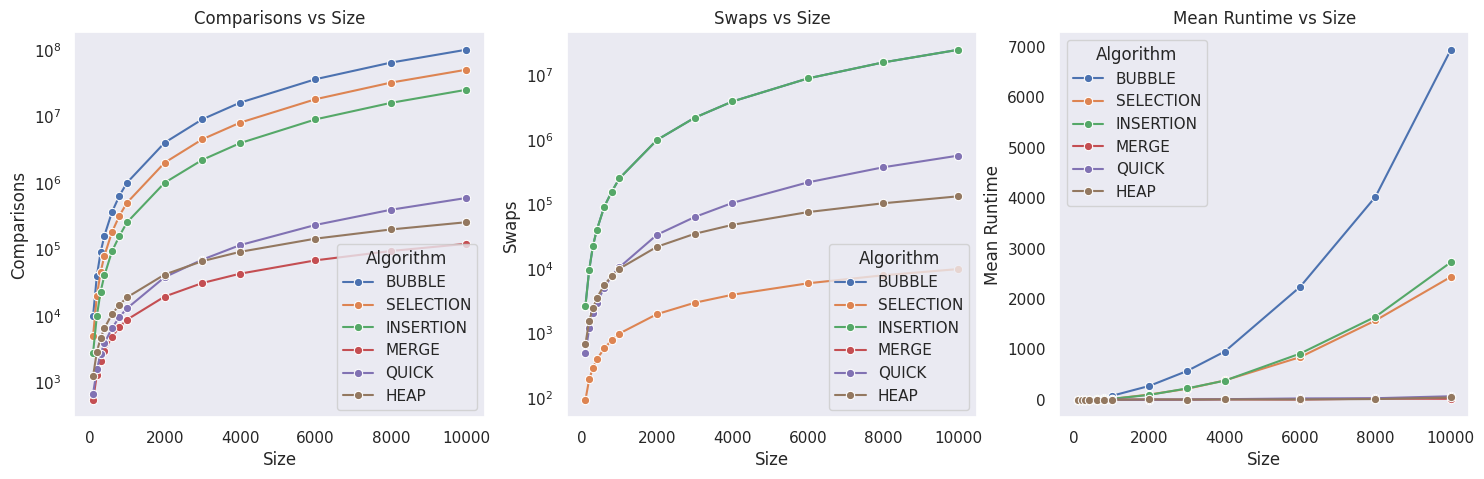

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [('Comparisons', 'log'), ('Swaps', 'log'), ('Mean Runtime', 'linear')]

for i, (metric, scale) in enumerate(metrics):
    sns.lineplot(data=df, x='Size', y=metric, hue='Algorithm', marker='o', ax=axes[i])
    axes[i].set_title(f'{metric} vs Size')
    axes[i].set_yscale(scale)
    axes[i].set_xscale('linear')



plt.show()